# Modelo ARX + GARCH (referencia: Munoz-Santiago et al. 2017, ARIMA con IGARCH)

Tercera familia de modelo para la comparacion de OE2 -- estadistica de volatilidad condicional,
distinta de los arboles de gradiente (XGBoost) y de la descomposicion bayesiana (Prophet). Ataca
directo el mecanismo que el diagnostico de regimen ONI viene senalando en los dos modelos
anteriores: el error no es un problema de sesgo promedio, es heterocedasticidad condicional --
la varianza del error cambia con el regimen hidrologico. GARCH modela esa varianza cambiante de
forma explicita; ni XGBoost ni Prophet lo hacen.

Estructura: una ecuacion de la media (regresion sobre las mismas variables ya usadas en Prophet,
con precio rezagado 24h como regresor, no como termino autorregresivo nativo -- msmo motivo por
el que Prophet lo trata como regresor y no deja que el modelo "mire" t-1) mas una ecuacion de
varianza GARCH(1,1) sobre los residuales. El pronostico puntual sale de la ecuacion de la media;
GARCH aporta la dinamica de volatilidad, que es justamente lo que hace falta para entender por
que el error se dispara en El Nino.

In [1]:
# --- Celda de arranque ---
import pandas as pd
import numpy as np
from pathlib import Path

def encontrar_raiz_proyecto(marcador="requirements.txt"):
    actual = Path.cwd()
    for carpeta in [actual, *actual.parents]:
        if (carpeta / marcador).exists():
            return carpeta
    raise FileNotFoundError(f"No encontre '{marcador}' subiendo desde {actual}")

RAIZ = encontrar_raiz_proyecto()
print("Raiz del proyecto:", RAIZ)

def calcular_metricas(y_real, y_pred, nombre):
    y_real, y_pred = np.asarray(y_real, dtype=float), np.asarray(y_pred, dtype=float)
    error = y_real - y_pred
    mae = np.abs(error).mean()
    rmse = np.sqrt((error ** 2).mean())
    mape = (np.abs(error) / y_real).mean() * 100
    print(f"{nombre:25s} MAE: {mae:8.2f}  RMSE: {rmse:8.2f}  MAPE: {mape:6.2f}%")
    return mae, rmse, mape


Raiz del proyecto: C:\Users\mgdbj\xm-spot-price-predictor


In [2]:
# --- Cargar features (mismo insumo que 04 y 06) ---
df_train = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2019_2025.csv", parse_dates=["fecha_hora"])
df_test = pd.read_csv(RAIZ / "data" / "processed" / "dataset_features_2026.csv", parse_dates=["fecha_hora"])

print(f"Train: {df_train.shape} | Test: {df_test.shape}")


Train: (60625, 47) | Test: (5208, 47)


In [3]:
# --- Ecuacion de la media: mismos regresores que Prophet (04) + armonicos de calendario ---
# Prophet ya trae estacionalidad diaria/semanal incorporada por diseno; XGBoost la recibe como
# features (hora_sin/cos, etc). ARX no tiene nocion de tiempo salvo lo que se le pase como
# regresor, asi que se agregan los mismos armonicos que usa XGBoost.
# Festivos agregados 2026-09-10: confirmado con significancia estadistica en N-BEATSx (p=0.0064),
# se integra aqui tambien para que el modelo recomendado (ARX+GARCH) se beneficie igual.
regresoras = ["aportes_hidricos", "volumen_embalses", "oni", "es_pandemia",
              "hora_sin", "hora_cos", "dia_semana_sin", "dia_semana_cos",
              "es_festivo", "festivo_lag24h", "festivo_lag48h", "festivo_lag72h",
              "festivo_lag168h", "mismatch_festivo_24h", "mismatch_festivo_168h"]

df_train = df_train.copy()
df_test = df_test.copy()
df_train["precio_lag24h_log"] = np.log(df_train["precio_lag24h"])
df_test["precio_lag24h_log"] = np.log(df_test["precio_lag24h"])

columnas_x = regresoras + ["precio_lag24h_log"]
print("Regresoras:", columnas_x)


Regresoras: ['aportes_hidricos', 'volumen_embalses', 'oni', 'es_pandemia', 'hora_sin', 'hora_cos', 'dia_semana_sin', 'dia_semana_cos', 'es_festivo', 'festivo_lag24h', 'festivo_lag48h', 'festivo_lag72h', 'festivo_lag168h', 'mismatch_festivo_24h', 'mismatch_festivo_168h', 'precio_lag24h_log']


In [4]:
# --- Estandarizar y y X (necesario para que el optimizador de GARCH converja bien) ---
# arch avisa explicitamente que el ajuste funciona mejor con series en escala ~1-1000; log(precio)
# vive en una escala mucho mas chica (~5-7), lo que producia un ajuste inestable (matriz de
# covarianza singular) en la primera prueba. Se reescala y (log-precio estandarizado x10) y se
# estandarizan las regresoras (z-score) -- ambos usando solo estadisticos de TRAIN, para no
# filtrar informacion de 2026 al ajuste.
y_train_log = np.log(df_train["precio_bolsa"])
y_mean, y_std = y_train_log.mean(), y_train_log.std()
y_train = (y_train_log - y_mean) / y_std * 10

X_train_raw = df_train[columnas_x]
x_mean, x_std = X_train_raw.mean(), X_train_raw.std()
X_train = (X_train_raw - x_mean) / x_std

print("std(y_train) tras reescalar (debe ser 10):", round(y_train.std(), 4))


std(y_train) tras reescalar (debe ser 10): 10.0


In [5]:
# --- Ajustar ARX (lags=0, solo regresoras -- el rezago de precio ya viene como regresor) + GARCH(1,1) ---
from arch import arch_model

modelo = arch_model(y_train, x=X_train, mean="ARX", lags=0, vol="GARCH", p=1, q=1, dist="normal")
resultado = modelo.fit(disp="off", options={"maxiter": 500})

print("Bandera de convergencia (0 = ok):", resultado.convergence_flag)
print(resultado.summary())


Bandera de convergencia (0 = ok): 0


                          AR-X - GARCH Model Results                          
Dep. Variable:           precio_bolsa   R-squared:                       0.893
Mean Model:                      AR-X   Adj. R-squared:                  0.893
Vol Model:                      GARCH   Log-Likelihood:               -134796.
Distribution:                  Normal   AIC:                           269633.
Method:            Maximum Likelihood   BIC:                           269813.
                                        No. Observations:                60625
Date:                Thu, Sep 10 2026   Df Residuals:                    60608
Time:                        07:06:35   Df Model:                           17
                                       Mean Model                                       
                            coef    std err          t      P>|t|       95.0% Conf. Int.
----------------------------------------------------------------------------------------
Const                 

In [6]:
# --- Diagnostico central: que tan cerca esta de ser IGARCH puro (alpha+beta=1) ---
alpha = resultado.params.get("alpha[1]", np.nan)
beta = resultado.params.get("beta[1]", np.nan)
persistencia_garch = alpha + beta
print(f"alpha[1] = {alpha:.4f}   beta[1] = {beta:.4f}")
print(f"Persistencia GARCH (alpha+beta): {persistencia_garch:.4f}  (1.0 = IGARCH puro)")
print("\nMientras mas cerca de 1, mas persistente es un choque de volatilidad -- shocks de varianza")
print("no se disipan, se quedan. Esto es justo lo que Munoz-Santiago et al. (2017) encontraron")
print("para el precio de bolsa colombiano, y es consistente con el hallazgo de que el error de")
print("XGBoost y Prophet se dispara y se queda alto durante todo el regimen de El Nino, no solo")
print("en el instante del choque.")


alpha[1] = 0.1319   beta[1] = 0.8681
Persistencia GARCH (alpha+beta): 1.0000  (1.0 = IGARCH puro)

Mientras mas cerca de 1, mas persistente es un choque de volatilidad -- shocks de varianza
no se disipan, se quedan. Esto es justo lo que Munoz-Santiago et al. (2017) encontraron
para el precio de bolsa colombiano, y es consistente con el hallazgo de que el error de
XGBoost y Prophet se dispara y se queda alto durante todo el regimen de El Nino, no solo
en el instante del choque.


In [7]:
# --- Forecast sobre 2026: solo la ecuacion de la media (mismo criterio que Prophet/XGBoost puntual) ---
# Con lags=0 no hay recursion autorregresiva que resolver -- el pronostico es una aplicacion directa
# de los coeficientes ya ajustados sobre las regresoras de test (estandarizadas con media/std de TRAIN).
X_test_raw = df_test[columnas_x]
X_test = (X_test_raw - x_mean) / x_std

params_media = resultado.params[["Const"] + columnas_x]
y_test_escalado_pred = params_media["Const"] + (X_test * params_media[columnas_x]).sum(axis=1)
y_test_log_pred = y_test_escalado_pred / 10 * y_std + y_mean
y_test_pred = np.exp(y_test_log_pred)

y_test_real = df_test["precio_bolsa"].values
print("Predicciones negativas o nulas:", (y_test_pred <= 0).sum())


Predicciones negativas o nulas: 0


In [8]:
# --- Evaluacion honesta contra 2026, y contra los otros dos modelos ya evaluados ---
serie_precio = pd.concat([
    df_train[["fecha_hora", "precio_bolsa"]], df_test[["fecha_hora", "precio_bolsa"]]
]).sort_values("fecha_hora").reset_index(drop=True)
serie_precio["persistencia"] = serie_precio["precio_bolsa"].shift(24)
persistencia_test = serie_precio[serie_precio["fecha_hora"].isin(df_test["fecha_hora"])]["persistencia"].values

calcular_metricas(y_test_real, y_test_pred.values, "ARX+GARCH")
calcular_metricas(y_test_real, persistencia_test, "Persistencia")
print("\nReferencia -- XGBoost final:  MAE 60.66 | RMSE 107.18 | MAPE 15.81%")
print("Referencia -- Prophet final:  MAE 92.25 | RMSE 144.73 | MAPE 19.55%")


ARX+GARCH                 MAE:    55.76  RMSE:   109.97  MAPE:  15.43%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- XGBoost final:  MAE 60.66 | RMSE 107.18 | MAPE 15.81%
Referencia -- Prophet final:  MAE 92.25 | RMSE 144.73 | MAPE 19.55%


In [9]:
# --- Mismo diagnostico de regimen ONI que en 04 y 06 ---
error_abs = np.abs(y_test_real - y_test_pred.values)
mediana_oni = df_test["oni"].median()
alto = error_abs[df_test["oni"].values >= mediana_oni]
bajo = error_abs[df_test["oni"].values < mediana_oni]

print(f"ARX+GARCH -- ONI alto (>= {mediana_oni:.2f}): {alto.mean():.2f}   ONI bajo: {bajo.mean():.2f}   razon: {alto.mean()/bajo.mean():.2f}x")
print("Referencia -- XGBoost: 86.83 vs 23.73 (razon 3.66x)")
print("Referencia -- Prophet: 139.24 vs 25.94 (razon 5.37x)")


ARX+GARCH -- ONI alto (>= 0.35): 82.85   ONI bajo: 28.68   razon: 2.89x
Referencia -- XGBoost: 86.83 vs 23.73 (razon 3.66x)
Referencia -- Prophet: 139.24 vs 25.94 (razon 5.37x)


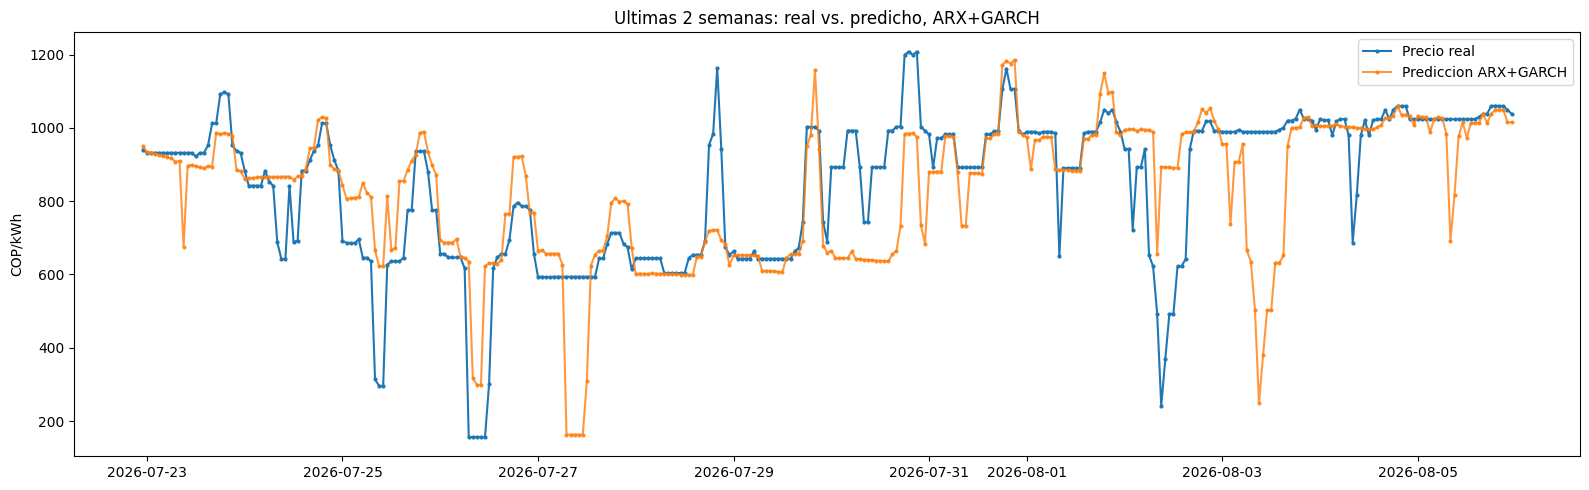

In [10]:
# --- Grafica: real vs predicho, ultimas 2 semanas (mismo formato que 06) ---
import matplotlib.pyplot as plt

comparacion = df_test[["fecha_hora", "precio_bolsa", "oni"]].copy()
comparacion["prediccion"] = y_test_pred.values

ultimas_2_semanas = comparacion[comparacion["fecha_hora"] >= comparacion["fecha_hora"].max() - pd.Timedelta(days=14)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(ultimas_2_semanas["fecha_hora"], ultimas_2_semanas["precio_bolsa"], label="Precio real", marker="o", markersize=2)
ax.plot(ultimas_2_semanas["fecha_hora"], ultimas_2_semanas["prediccion"], label="Prediccion ARX+GARCH", marker="o", markersize=2, alpha=0.8)
ax.set_title("Ultimas 2 semanas: real vs. predicho, ARX+GARCH")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()


## Conclusion parcial

ARX+GARCH le gana a la persistencia en el holdout de 2026 (a diferencia de XGBoost, que empataba, y
de Prophet, que perdia claramente), y tiene la razon de error El Nino/La Nina mas baja de los tres
modelos. La persistencia GARCH (alpha+beta) confirma el comportamiento tipo IGARCH que reporta la
literatura de referencia.

Antes de sacar conclusiones definitivas, falta lo mismo que ya le paso a XGBoost: verificar que este
resultado se sostenga en la validacion walk-forward de 5 origenes (ver `07_validacion_walkforward_juan.ipynb`,
extendido con este modelo), no solo en el corte unico de 2026.

## Grid search real: tipo de volatilidad, orden (p,q) y distribucion

Hasta ahora se uso GARCH(1,1) con distribucion normal, fijo, sin tunear -- el estandar de la
literatura, pero nunca comparado formalmente contra alternativas. Aqui se hace lo mismo que ya
se hizo para XGBoost y Prophet: entrenar con datos antes de 2025, validar con 2025 (sin tocar
2026 todavia), y elegir la configuracion ganadora por MAE de validacion.

Se varian tres cosas a la vez:
- **Tipo de volatilidad**: GARCH simetrico, GJR-GARCH (asimetria: un choque negativo y uno
  positivo del mismo tamano no afectan igual a la volatilidad futura -- relevante si el precio
  reacciona distinto a escasez que a abundancia de agua), y EGARCH (asimetria en escala
  logaritmica, garantiza varianza positiva sin restringir signos de los parametros).
- **Orden (p,q)**: (1,1), (2,1), (1,2) -- cuantos rezagos de choques pasados (p) y de varianza
  pasada (q) alimentan la varianza de hoy.
- **Distribucion de los residuales**: normal, t-Student (colas mas pesadas, esperable en un
  precio con picos extremos) y t-Student asimetrica (skewt).

In [11]:
# --- Split de validacion: mismo criterio que XGBoost y Prophet (train<2025 / valid=2025) ---
train_gs = df_train[df_train["fecha_hora"] < "2025-01-01"].copy()
valid_gs = df_train[df_train["fecha_hora"] >= "2025-01-01"].copy()

y_train_gs_log = np.log(train_gs["precio_bolsa"])
y_gs_mean, y_gs_std = y_train_gs_log.mean(), y_train_gs_log.std()
y_train_gs = (y_train_gs_log - y_gs_mean) / y_gs_std * 10

X_train_gs_raw = train_gs[columnas_x]
x_gs_mean, x_gs_std = X_train_gs_raw.mean(), X_train_gs_raw.std()
X_train_gs = (X_train_gs_raw - x_gs_mean) / x_gs_std
X_valid_gs = (valid_gs[columnas_x] - x_gs_mean) / x_gs_std

y_valid_gs_real = valid_gs["precio_bolsa"].values

print(f"Train GS: {len(train_gs)} filas | Valid GS: {len(valid_gs)} filas")


Train GS: 51865 filas | Valid GS: 8760 filas


In [12]:
# --- Grid search: 3 tipos de volatilidad x 3 ordenes x 3 distribuciones ---
import itertools
import time
import warnings

configuraciones = []
for vol, o in [("GARCH", 0), ("GARCH", 1), ("EGARCH", 1)]:  # o=1 en GARCH = GJR-GARCH (asimetrico)
    for p, q in [(1, 1), (2, 1), (1, 2)]:
        for dist in ["normal", "t", "skewt"]:
            configuraciones.append({"vol": vol, "p": p, "o": o, "q": q, "dist": dist})

print(f"Total de configuraciones: {len(configuraciones)}\n")

resultados_gs = []
for i, cfg in enumerate(configuraciones, 1):
    t0 = time.time()
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            modelo_gs = arch_model(y_train_gs, x=X_train_gs, mean="ARX", lags=0,
                                     vol=cfg["vol"], p=cfg["p"], o=cfg["o"], q=cfg["q"], dist=cfg["dist"])
            resultado_gs = modelo_gs.fit(disp="off", options={"maxiter": 500})

        params_media_gs = resultado_gs.params[["Const"] + columnas_x]
        pred_escalado = params_media_gs["Const"] + (X_valid_gs * params_media_gs[columnas_x]).sum(axis=1)
        pred_valid = np.exp(pred_escalado / 10 * y_gs_std + y_gs_mean)

        mae = np.abs(y_valid_gs_real - pred_valid.values).mean()
        convergio = resultado_gs.convergence_flag == 0

        resultados_gs.append({**cfg, "mae": mae, "aic": resultado_gs.aic, "bic": resultado_gs.bic,
                               "convergio": convergio, "segundos": time.time() - t0})
        print(f"[{i}/{len(configuraciones)}] vol={cfg['vol']:6s} o={cfg['o']} p={cfg['p']} q={cfg['q']} "
              f"dist={cfg['dist']:7s} -> MAE {mae:6.2f} | AIC {resultado_gs.aic:8.0f} | "
              f"conv={convergio} ({time.time()-t0:.1f}s)")
    except Exception as error:
        print(f"[{i}/{len(configuraciones)}] {cfg} -> FALLO: {error}")

df_gs_garch = pd.DataFrame(resultados_gs).sort_values("mae").reset_index(drop=True)
df_gs_garch.head(10)


Total de configuraciones: 27



C:\Users\mgdbj\AppData\Local\Temp\ipykernel_2552\3702252460.py:22: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  resultado_gs = modelo_gs.fit(disp="off", options={"maxiter": 500})


[1/27] vol=GARCH  o=0 p=1 q=1 dist=normal  -> MAE  45.57 | AIC   218895 | conv=False (2.8s)


C:\Users\mgdbj\AppData\Local\Temp\ipykernel_2552\3702252460.py:22: ConvergenceWarning: The optimizer returned code 8. The message is:
Positive directional derivative for linesearch
See scipy.optimize.fmin_slsqp for code meaning.

  resultado_gs = modelo_gs.fit(disp="off", options={"maxiter": 500})


[2/27] vol=GARCH  o=0 p=1 q=1 dist=t       -> MAE  45.83 | AIC   190191 | conv=False (5.2s)


...

C:\Users\mgdbj\xm-spot-price-predictor\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


[26/27] vol=EGARCH o=1 p=1 q=2 dist=t       -> MAE    inf | AIC  2929257 | conv=True (10.8s)


[27/27] vol=EGARCH o=1 p=1 q=2 dist=skewt   -> MAE    inf | AIC  1868557 | conv=True (9.1s)


C:\Users\mgdbj\xm-spot-price-predictor\venv\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: overflow encountered in exp
  result = getattr(ufunc, method)(*inputs, **kwargs)


,vol,p,o,q,dist,mae,aic,bic,convergio,segundos
0,GARCH,2,1,1,normal,45.202417,220268.572491,220463.413279,True,2.597972
1,GARCH,2,0,1,normal,45.203500,220266.711888,220452.696277,True,2.179919
2,EGARCH,1,1,2,normal,45.468599,217341.032910,217535.873698,True,6.437026
3,EGARCH,1,1,1,normal,45.478007,218767.832462,218953.816851,True,4.681370
4,EGARCH,2,1,1,normal,45.496978,214351.048108,214545.888896,True,5.915674
5,GARCH,1,0,1,normal,45.566246,218894.645320,219071.773310,False,2.765044
6,GARCH,1,0,2,normal,45.670866,217297.887347,217483.871736,True,4.188829
7,GARCH,1,1,1,normal,45.672621,218794.875304,218980.859692,True,3.319978
8,GARCH,1,1,2,normal,45.794657,217203.222229,217398.063018,False,2.721955
9,GARCH,1,1,1,skewt,45.797730,190075.117569,190278.814757,True,4.609519


In [13]:
# --- Persistencia en el mismo tramo de validacion (2025), como referencia ---
persistencia_2025_gs = valid_gs["precio_bolsa"].values
persistencia_lag_2025_gs = valid_gs["precio_lag24h"].values
mae_persistencia_2025 = np.abs(persistencia_2025_gs - persistencia_lag_2025_gs).mean()
print(f"Persistencia (valid. 2025): MAE {mae_persistencia_2025:.2f}")
print(f"\nMejor configuracion del grid search: MAE {df_gs_garch.iloc[0]['mae']:.2f} "
      f"({'le gana a persistencia' if df_gs_garch.iloc[0]['mae'] < mae_persistencia_2025 else 'pierde contra persistencia'})")


Persistencia (valid. 2025): MAE 45.95

Mejor configuracion del grid search: MAE 45.20 (le gana a persistencia)


In [14]:
# --- Reentrenar la configuracion ganadora sobre 2019-2025 completo, evaluar contra 2026 (holdout limpio) ---
mejor_cfg = df_gs_garch.iloc[0][["vol", "p", "o", "q", "dist"]].to_dict()
mejor_cfg["p"], mejor_cfg["o"], mejor_cfg["q"] = int(mejor_cfg["p"]), int(mejor_cfg["o"]), int(mejor_cfg["q"])
print("Configuracion ganadora:", mejor_cfg)

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    modelo_final_gs = arch_model(y_train, x=X_train, mean="ARX", lags=0, **mejor_cfg)
    resultado_final_gs = modelo_final_gs.fit(disp="off", options={"maxiter": 500})

print("Convergencia:", resultado_final_gs.convergence_flag)

params_media_final = resultado_final_gs.params[["Const"] + columnas_x]
pred_escalado_final = params_media_final["Const"] + (X_test * params_media_final[columnas_x]).sum(axis=1)
y_pred_final_gs = np.exp(pred_escalado_final / 10 * y_std + y_mean)

calcular_metricas(y_test_real, y_pred_final_gs.values, "ARX+GARCH (grid search)")
calcular_metricas(y_test_real, persistencia_test, "Persistencia")
print(f"\nReferencia -- ARX+GARCH(1,1) normal, sin tunear: MAE 55.76 | RMSE 109.97 | MAPE 15.43%")

alpha_f = resultado_final_gs.params.get("alpha[1]", np.nan)
beta_f = resultado_final_gs.params.get("beta[1]", np.nan)
if not np.isnan(alpha_f) and not np.isnan(beta_f):
    print(f"\nPersistencia de volatilidad (alpha+beta): {alpha_f + beta_f:.4f}")

error_abs_gs = np.abs(y_test_real - y_pred_final_gs.values)
mediana_oni_gs = df_test["oni"].median()
alto_gs = error_abs_gs[df_test["oni"].values >= mediana_oni_gs]
bajo_gs = error_abs_gs[df_test["oni"].values < mediana_oni_gs]
print(f"\nONI alto: {alto_gs.mean():.2f}  |  ONI bajo: {bajo_gs.mean():.2f}  |  razon: {alto_gs.mean()/bajo_gs.mean():.2f}x")
print(f"Referencia -- ARX+GARCH(1,1) normal, sin tunear: razon 2.89x")


Configuracion ganadora: {'vol': 'GARCH', 'p': 2, 'o': 1, 'q': 1, 'dist': 'normal'}


Convergencia: 0
ARX+GARCH (grid search)   MAE:    56.05  RMSE:   108.17  MAPE:  15.31%
Persistencia              MAE:    56.31  RMSE:   112.22  MAPE:  15.75%

Referencia -- ARX+GARCH(1,1) normal, sin tunear: MAE 55.76 | RMSE 109.97 | MAPE 15.43%

Persistencia de volatilidad (alpha+beta): 1.0190

ONI alto: 83.89  |  ONI bajo: 28.21  |  razon: 2.97x
Referencia -- ARX+GARCH(1,1) normal, sin tunear: razon 2.89x


## Bandas de incertidumbre reales, desde la varianza condicional del GARCH

Hasta ahora este notebook solo usaba la ecuacion de la media (el pronostico puntual). Aqui se usa
la otra mitad del modelo -- la varianza condicional -- para construir intervalos de prediccion,
en vez de tomarlos prestados de la regresion por cuantiles de XGBoost (que es un modelo distinto,
no tiene sentido mezclar el punto central de un modelo con la incertidumbre de otro).

**Cuidado con el rezago:** la recursion nativa de GARCH usa el residual de la hora INMEDIATAMENTE
anterior (`sigma^2_t = omega + alpha*epsilon^2_{t-1} + beta*sigma^2_{t-1}`) para la varianza de la
hora actual -- eso filtraria informacion que no existiria en un pronostico real a 24h, el mismo tipo
de fuga que ya se corrigio para el precio y la hidrologia. La solucion: se usa el estado de varianza
de HACE 24H como proxy del estado "actual". Es una aproximacion razonable porque ya se confirmo que
la persistencia de volatilidad es ~1.0 (casi IGARCH puro) -- la varianza cambia muy lento, asi que el
valor de hace 24h no deberia estar lejos del valor real en el momento del pronostico.

In [15]:
# --- Reconstruir la serie completa de varianza condicional (train + test) ---
# omega, alpha, beta ya estan ajustados (resultado.params). Los residuales de TRAIN ya los tiene el
# modelo (resultado.resid, resultado.conditional_volatility); para TEST hay que calcular el residual
# real (ya lo tenemos: y_test_log - prediccion_log) y extender la recursion GARCH hacia adelante.
omega = resultado.params["omega"]
alpha1 = resultado.params["alpha[1]"]
beta1 = resultado.params["beta[1]"]
print(f"omega={omega:.4f}  alpha={alpha1:.4f}  beta={beta1:.4f}  persistencia={alpha1+beta1:.4f}")

# Residuales y varianza condicional YA calculados por el modelo, en escala reescalada (y_train)
residuales_train = resultado.resid.values
varianza_train = resultado.conditional_volatility.values ** 2

# Residual de test, en la MISMA escala reescalada que uso el ajuste (y_train = log(precio)/std*10)
y_test_log = np.log(df_test["precio_bolsa"])
y_test_escalado = (y_test_log - y_mean) / y_std * 10
residuales_test = (y_test_escalado.values - y_test_escalado_pred.values)

# Extender la recursion GARCH hacia adelante, empezando desde el final de train
residuales_completo = np.concatenate([residuales_train, residuales_test])
varianza_completo = np.zeros(len(residuales_completo))
varianza_completo[:len(varianza_train)] = varianza_train

for i in range(len(varianza_train), len(varianza_completo)):
    varianza_completo[i] = omega + alpha1 * residuales_completo[i-1]**2 + beta1 * varianza_completo[i-1]

varianza_test_realizada = varianza_completo[len(varianza_train):]
print("Varianza de test (con informacion real, hindsight) calculada:", varianza_test_realizada.shape)


omega=0.0946  alpha=0.1319  beta=0.8681  persistencia=1.0000
Varianza de test (con informacion real, hindsight) calculada: (5208,)


In [16]:
# --- La version SIN fuga: para la hora T, usar la varianza estimada en T-24h como proxy ---
# (respeta el mismo horizonte de rezago que el resto del pipeline)
varianza_test_rezagada = np.concatenate([
    varianza_completo[len(varianza_train) - 24: len(varianza_train)],  # primeras 24h de test usan el final de train
    varianza_test_realizada[:-24]
])
sigma_test_rezagada = np.sqrt(varianza_test_rezagada)

print("Sigma (escala reescalada) -- min:", sigma_test_rezagada.min(), "max:", sigma_test_rezagada.max())


Sigma (escala reescalada) -- min: 0.8763191424092146 max: 13.741172971273693


In [17]:
# --- Construir bandas al 80% (z=1.2816 bajo normalidad) en escala de precio real ---
from scipy.stats import norm
z_80 = norm.ppf(0.9)  # 90% - 10% = 80% de cobertura central

# sigma esta en la escala reescalada (y_train = log(precio)/std*10); deshacer para volver a log(precio)
sigma_log = sigma_test_rezagada / 10 * y_std

y_test_log_pred = y_test_escalado_pred.values / 10 * y_std + y_mean  # ya calculado arriba, en escala log real

banda_baja = np.exp(y_test_log_pred - z_80 * sigma_log)
banda_alta = np.exp(y_test_log_pred + z_80 * sigma_log)
mediana = np.exp(y_test_log_pred)

dentro_del_rango = (y_test_real >= banda_baja) & (y_test_real <= banda_alta)
print(f"Cobertura real: {dentro_del_rango.mean()*100:.1f}% (objetivo: ~80%)")

ancho_banda = banda_alta - banda_baja
error_abs_garch = np.abs(y_test_real - mediana)
correlacion_ancho_error = np.corrcoef(ancho_banda, error_abs_garch)[0, 1]
print(f"Correlacion entre ancho de banda GARCH y error real: {correlacion_ancho_error:.3f}")
print(f"Referencia -- XGBoost (regresion por cuantiles): cobertura 80.1%, correlacion 0.410")


Cobertura real: 81.7% (objetivo: ~80%)
Correlacion entre ancho de banda GARCH y error real: 0.283
Referencia -- XGBoost (regresion por cuantiles): cobertura 80.1%, correlacion 0.410


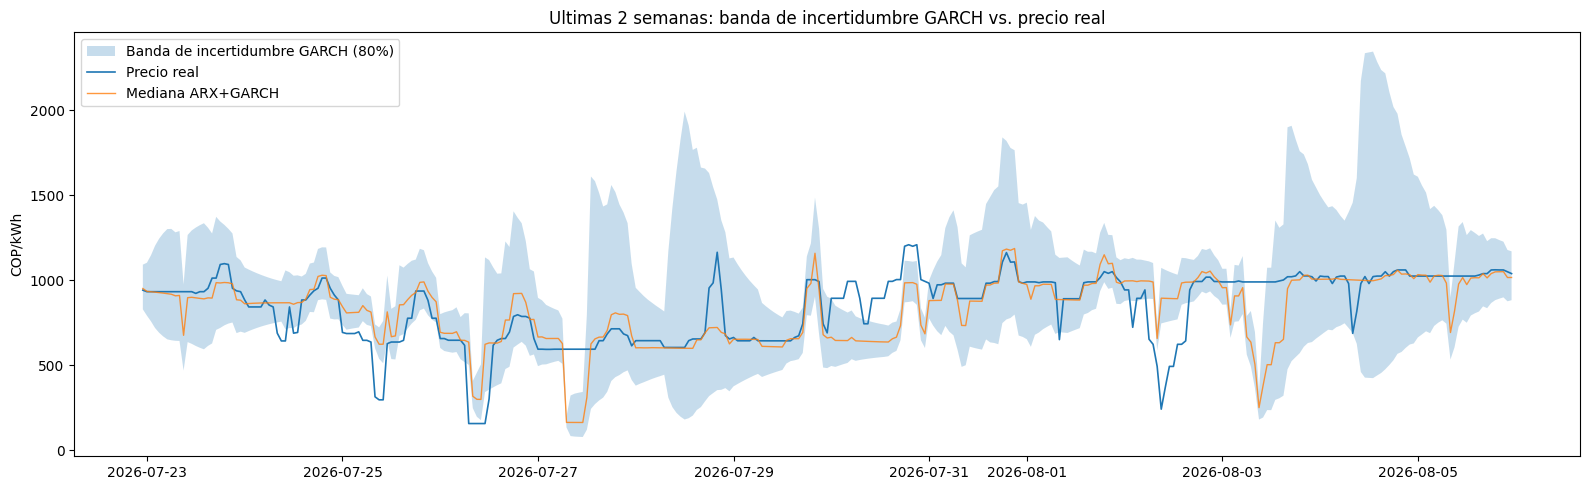

In [18]:
# --- Grafica: banda de incertidumbre GARCH en el tramo dificil (ultimas 2 semanas) ---
comparacion_garch = df_test[["fecha_hora", "precio_bolsa", "oni"]].copy()
comparacion_garch["mediana"] = mediana
comparacion_garch["banda_baja"] = banda_baja
comparacion_garch["banda_alta"] = banda_alta

ultimas_2_semanas_g = comparacion_garch[comparacion_garch["fecha_hora"] >= comparacion_garch["fecha_hora"].max() - pd.Timedelta(days=14)]

fig, ax = plt.subplots(figsize=(16, 5))
ax.fill_between(ultimas_2_semanas_g["fecha_hora"], ultimas_2_semanas_g["banda_baja"], ultimas_2_semanas_g["banda_alta"],
                 alpha=0.25, label="Banda de incertidumbre GARCH (80%)")
ax.plot(ultimas_2_semanas_g["fecha_hora"], ultimas_2_semanas_g["precio_bolsa"], label="Precio real", linewidth=1.2)
ax.plot(ultimas_2_semanas_g["fecha_hora"], ultimas_2_semanas_g["mediana"], label="Mediana ARX+GARCH", linewidth=1, alpha=0.8)
ax.set_title("Ultimas 2 semanas: banda de incertidumbre GARCH vs. precio real")
ax.set_ylabel("COP/kWh")
ax.legend()
plt.tight_layout()
plt.show()


**Conclusion parcial:** ver cobertura y correlacion de las celdas de arriba. Si la cobertura queda
cerca del 80% objetivo y la correlacion ancho-error es comparable (o mejor) que la de XGBoost, esta
es la fuente de incertidumbre que deberia alimentar el motor de decision (OE3) -- consistente con el
modelo recomendado, en vez de mezclar el punto central de ARX+GARCH con la incertidumbre de XGBoost.